Vị trí tối ưu: [ 0.00078264 -0.00051449]
Giá trị tối ưu: 8.772233e-07


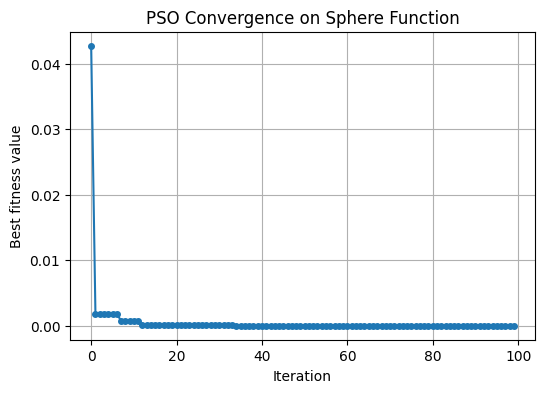

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def sphere(x):
    """
    Hàm Sphere: f(x) = sum(x_i^2)
    Input:
      x: mảng 1-D kích thước dim
    Output:
      Giá trị hàm tại x
    """
    return np.sum(x**2)

class Particle:
    def __init__(self, dim, bounds):
        """
        dim    : số chiều
        bounds : [min, max] cho mỗi chiều
        """
        # Vị trí và vận tốc ban đầu
        self.position = np.random.uniform(bounds[0], bounds[1], size=dim)
        self.velocity = np.zeros(dim)
        # pbest khởi tạo là vị trí ban đầu
        self.best_pos = self.position.copy()
        self.best_val = sphere(self.position)

def pso_sphere(dim, bounds, n_particles=30, iters=100, w=0.8, c1=2.0, c2=2.0):
    """
    PSO tối ưu hàm Sphere
    dim        : số chiều
    bounds     : [min, max] cho mọi chiều
    n_particles: số hạt trong swarm
    iters      : số lần lặp
    w          : trọng số quán tính
    c1, c2     : hệ số học tập cá nhân và xã hội
    """
    # Khởi tạo swarm
    swarm = [Particle(dim, bounds) for _ in range(n_particles)]
    # Khởi tạo gbest
    gbest_val = float('inf')
    gbest_pos = None

    history = []  # Lưu giá trị gbest qua các iteration

    for t in range(iters):
        for p in swarm:
            fitness = sphere(p.position)
            # Cập nhật pbest
            if fitness < p.best_val:
                p.best_val = fitness
                p.best_pos = p.position.copy()
            # Cập nhật gbest
            if fitness < gbest_val:
                gbest_val = fitness
                gbest_pos = p.position.copy()

        # Cập nhật vận tốc và vị trí cho mỗi hạt
        for p in swarm:
            r1 = np.random.rand(dim)
            r2 = np.random.rand(dim)
            cognitive = c1 * r1 * (p.best_pos - p.position)
            social    = c2 * r2 * (gbest_pos   - p.position)
            p.velocity = w * p.velocity + cognitive + social
            p.position += p.velocity

        history.append(gbest_val)

    return gbest_pos, gbest_val, history

if __name__ == "__main__":
    # Thông số demo
    dim = 2
    bounds = [-5, 5]
    n_particles = 40
    iters = 100

    # Chạy PSO
    best_pos, best_val, hist = pso_sphere(dim, bounds, n_particles, iters)

    print(f"Vị trí tối ưu: {best_pos}")
    print(f"Giá trị tối ưu: {best_val:.6e}")

    # Vẽ đồ thị hội tụ
    plt.figure(figsize=(6,4))
    plt.plot(hist, '-o', markersize=4)
    plt.xlabel('Iteration')
    plt.ylabel('Best fitness value')
    plt.title('PSO Convergence on Sphere Function')
    plt.grid(True)
    plt.show()


Best route: [0, 1, 5, 4, 7, 2, 3, 6]
Best length: 2.787070050244542


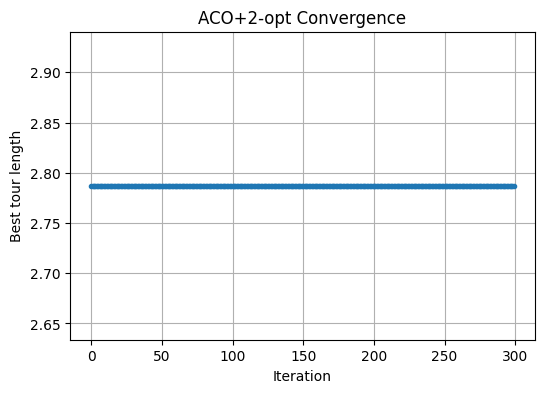

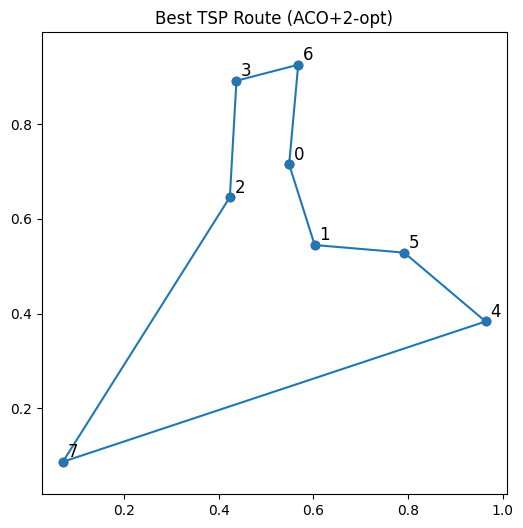

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def two_opt(route, dist):
    """Áp dụng 2-opt local search để cải thiện một tour."""
    best = route
    improved = True
    n = len(route)
    while improved:
        improved = False
        for i in range(1, n-2):
            for j in range(i+1, n):
                if j - i == 1: continue
                new_route = best[:i] + best[i:j][::-1] + best[j:]
                # tính độ dài mới
                old_len = sum(dist[best[k], best[(k+1)%n]] for k in range(n))
                new_len = sum(dist[new_route[k], new_route[(k+1)%n]] for k in range(n))
                if new_len < old_len:
                    best = new_route
                    improved = True
        route = best
    return best

def aco_tsp_with_2opt(coords, ants=30, iters=200, alpha=1.0, beta=5.0, rho=0.1, Q=100):
    """
    ACO + 2-opt for TSP.
    coords : mảng (n,2) tọa độ thành phố
    """
    n = len(coords)
    # Ma trận khoảng cách
    dist = np.sqrt(((coords[:,None,:] - coords[None,:,:])**2).sum(axis=2))
    np.fill_diagonal(dist, np.inf)
    # Khởi tạo pheromone và heuristic
    pher = np.ones((n,n))
    heuristic = 1.0 / dist

    best_len = np.inf
    best_route = None
    history = []

    for iteration in range(iters):
        all_routes = []
        all_lengths = []
        for _ in range(ants):
            # Khởi tạo start random
            route = [np.random.randint(n)]
            while len(route) < n:
                i = route[-1]
                probs = (pher[i]**alpha) * (heuristic[i]**beta)
                probs[route] = 0
                probs = probs / probs.sum()
                next_city = np.random.choice(n, p=probs)
                route.append(next_city)
            # 2-opt local improvement
            route = two_opt(route, dist)
            # tính độ dài
            length = sum(dist[route[k], route[(k+1)%n]] for k in range(n))
            all_routes.append(route)
            all_lengths.append(length)
            if length < best_len:
                best_len = length
                best_route = route.copy()

        # Bay hơi pheromone
        pher *= (1 - rho)
        # Deposit theo mỗi tour
        for route, length in zip(all_routes, all_lengths):
            for k in range(n):
                i,j = route[k], route[(k+1)%n]
                pher[i,j] += Q/length
                pher[j,i] += Q/length

        history.append(best_len)

    return best_route, best_len, history

if __name__ == "__main__":
    # Tọa độ ngẫu nhiên cho 8 thành phố
    np.random.seed(0)
    coords = np.random.rand(8,2)

    # Chạy ACO+2opt
    route, length, history = aco_tsp_with_2opt(coords,
                                               ants=40,
                                               iters=300,
                                               alpha=1.0,
                                               beta=5.0,
                                               rho=0.1,
                                               Q=100)
    print("Best route:", route)
    print("Best length:", length)

    # Vẽ hội tụ
    plt.figure(figsize=(6,4))
    plt.plot(history, '-o', markersize=3)
    plt.xlabel('Iteration')
    plt.ylabel('Best tour length')
    plt.title('ACO+2-opt Convergence')
    plt.grid(True)

    # Vẽ bản đồ route cuối
    plt.figure(figsize=(6,6))
    xs, ys = coords[:,0], coords[:,1]
    plt.scatter(xs, ys, c='red')
    for i, (x,y) in enumerate(coords):
        plt.text(x+0.01, y+0.01, str(i), fontsize=12)
    # nối route
    rr = route + [route[0]]
    plt.plot(coords[rr,0], coords[rr,1], '-o')
    plt.title('Best TSP Route (ACO+2-opt)')
    plt.axis('equal')
    plt.show()
